# **Titanic - Machine Learning from Disaster v2**

## **0. Project Overveiw**

### **Objective**

- **Titanic - Machine Learning from Disaster v1 성능 강화**
  - **EDA** : 구체적인 데이터 분석을 통해 데이터와 생존여부 관계 파악
  - **Feature Engineering** : 데이터 가공
  - **Model Benchmarking** : 모델에 따른 결과 비교, 평가

### **Goal**

**타이타닉호 탑승객의 정보를 바탕으로 생존 여부를 예측하는 모델 구축**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## **1. EDA**

In [2]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### **Name** 

이름에서 호칭을 추출하고, 호칭에 따른 인원수와 생존율을 확인한다.

- 남성 호칭(Mr, Master 등)을 가진 사람의 비율이 여성 호칭(Miss, Mrs) 보다 많음을 확인할 수 있다.
- 여성 호칭(Mrs, Miss)의 생존율이 높음을 확인할 수 있다.
- 남성 호칭 간에도 상대적으로 어린 소년에게 붙이는 호칭인 Master 의 생존율이 더 높음을 확인할 수 있다.

In [4]:
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(train['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


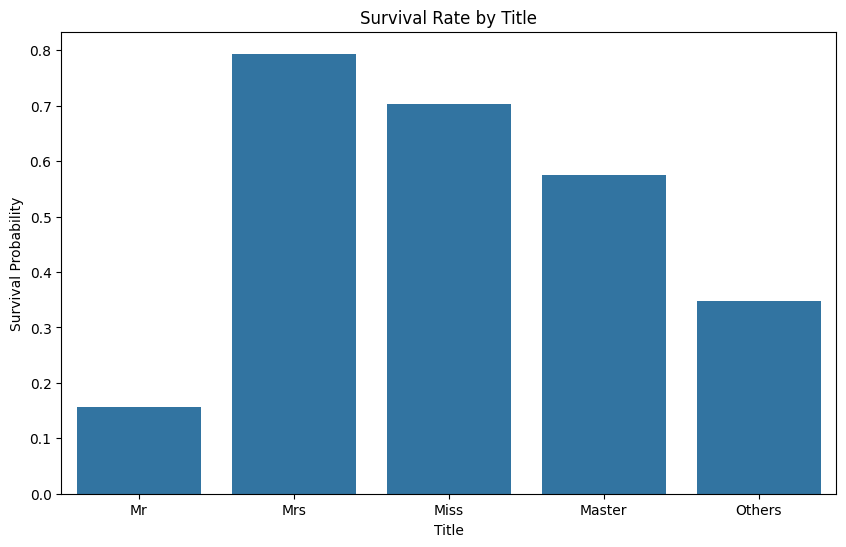

In [5]:
train['Title'] = train['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Others')
train['Title'] = train['Title'].replace(['Mlle', 'Ms'], 'Miss')
train['Title'] = train['Title'].replace('Mme', 'Mrs')

plt.figure(figsize=(10,6))
sns.barplot(x='Title', y='Survived', data=train, errorbar=None)
plt.title('Survival Rate by Title')
plt.ylabel('Survival Probability')
plt.show()

### **Sex & Age**

성별과 나이에 따른 인원수와 생존율을 확인한다.
- 10세 미만의 경우 성별과 관계 없이 높은 생존율을 보이고 있다.
- 10대 이상부터는 여성이 남성보다 현저히 높은 생존율을 보였음을 확인할 수 있다.

In [6]:
train['Age_temp'] = train['Age'].fillna(train['Age'].mean())
train['Age_group'] = (train['Age_temp'] // 10).astype(int)

print(train['Age_group'].value_counts())

Age_group
2    397
3    167
1    102
4     89
0     62
5     48
6     19
7      6
8      1
Name: count, dtype: int64


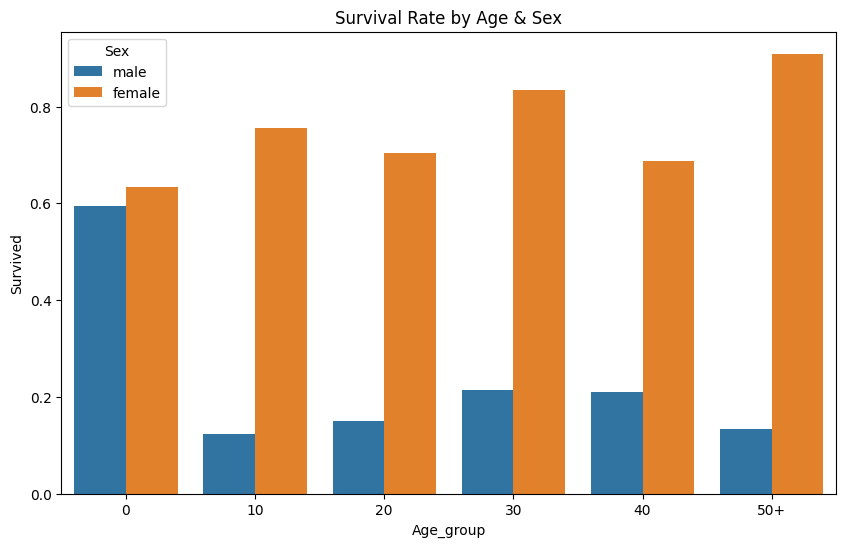

In [7]:
train['Age_group'] = train['Age_group'].replace([5, 6, 7, 8], 5)

plt.figure(figsize=(10, 6))
sns.barplot(x='Age_group', y='Survived', hue='Sex', data=train, errorbar=None)
plt.xticks(ticks=range(6), labels=['0', '10', '20', '30', '40', '50+'])
plt.title('Survival Rate by Age & Sex')
plt.show()

### **Sibsp & Parch**

가족 수에 따른 생존율을 확인한다.
- 1인 승객의 생존율에 비해 2~4인이 함께 탄 경우 생존율이 높은 것으로 확인된다.
- 5인 이상의 승객들이 함께 탄 경우 생존율이 급격하게 낮아짐을 확인할 수 있다.
- 가족 수 & 성별을 통해 가족 수에 따른 여성의 생존 비율은 거의 동일하나 남성의 생존 비율에는 차이가 있음을 알 수 있다.
  - 이는 1,2인에 비해 3,4인 가족의 경우 아이가 포함되어 있는 비율이 높아 그런것으로 추정된다.

In [8]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
print(train['FamilySize'].value_counts())

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64


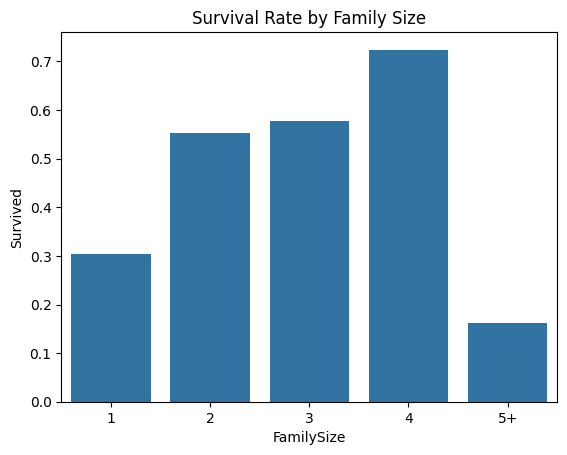

In [9]:
train['FamilySize'] = train['FamilySize'].replace([5, 6, 7, 8, 11], 5)

sns.barplot(x='FamilySize', y='Survived', data=train, errorbar=None)
plt.xticks(ticks=range(5), labels=['1', '2', '3', '4', '5+'])
plt.title('Survival Rate by Family Size')
plt.show()

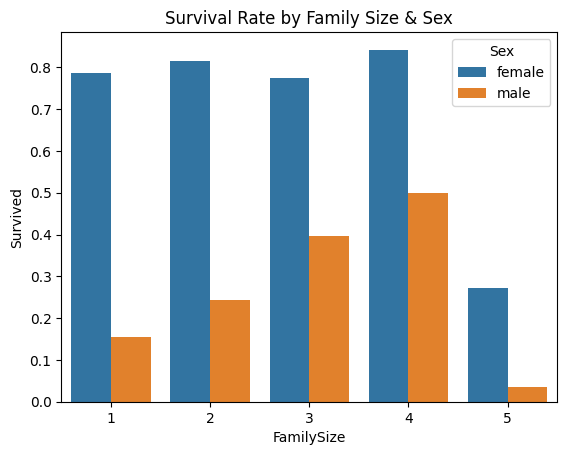

In [10]:
sns.barplot(x='FamilySize', y='Survived', hue='Sex', data=train, errorbar=None)
plt.title('Survival Rate by Family Size & Sex')
plt.show()

In [11]:
family_age_table = pd.crosstab(train['FamilySize'], train['Age_group'])
print(family_age_table)

Age_group    0   1    2    3   4   5
FamilySize                          
1            1  53  281  105  49  48
2            6  23   63   31  22  16
3           22  13   26   21  12   8
4           10   2   10    6   1   0
5           23  11   17    4   5   2


### **Pclass, Fare & Others**

사회적 계급에 따른 생존율을 확인한다.

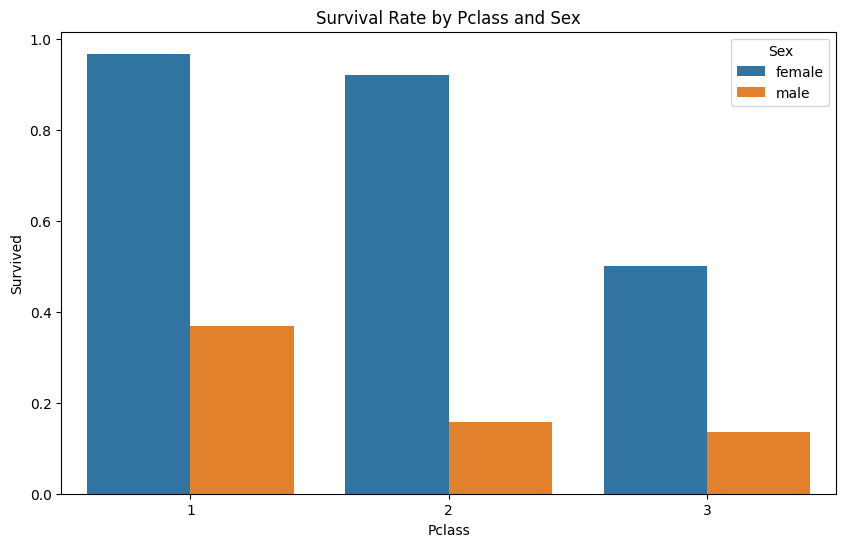

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train, errorbar=None)
plt.title('Survival Rate by Pclass and Sex')
plt.show()

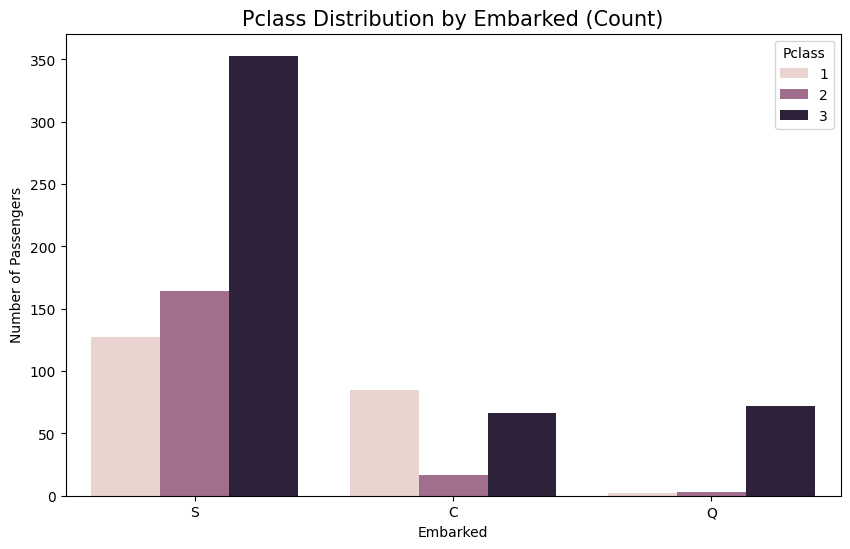

In [13]:
plt.figure(figsize=(10, 6))

sns.countplot(x='Embarked', hue='Pclass', data=train)

plt.title('Pclass Distribution by Embarked (Count)', fontsize=15)
plt.xlabel('Embarked')
plt.ylabel('Number of Passengers')
plt.show()

## **2. Preprocessing**

### **Missing Value**

결측치 채우기
1. Age - Title 별 중앙값으로 Age 를 채운다.
2. Embarked - 최빈값인 S 로 채운다.
3. Fare - Pclass 별 평균값으로 Fare 을 채운다


#### **AGE**

In [15]:
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

combine = [train, test]

for dataset in combine:
    dataset['Title'] = dataset['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Others')
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

In [16]:
train["Age"] = train["Age"].fillna(train.groupby("Title")["Age"].transform("median"))
test["Age"] = test["Age"].fillna(test.groupby("Title")["Age"].transform("median"))

print(f"Train Age 결측치 개수: {train['Age'].isnull().sum()}")
print(f"Test Age 결측치 개수: {test['Age'].isnull().sum()}")

Train Age 결측치 개수: 0
Test Age 결측치 개수: 0


#### **Embarked & Fare**

In [17]:
train['Embarked'] = train['Embarked'].fillna('S')
test['Fare'] = test['Fare'].fillna(test.groupby("Pclass")["Fare"].transform("median"))

### **Feature Engineering**

EDA 에서 발견한 특성에 따라 데이터를 가공한다.
- Name 에서 Title 을 추출한다.
- SibSp 와 Parch 을 그룹화하고, 비슷한 생존율을 보였던 그룹으로 묶는다.
- Age 를 범주화한다.
  1. 데이터의 노이즈 제거 : 1,2살 차이의 생존확률에는 유의미한 차이가 없음. 범주화를 통해 과적합 방지
  2. 비선형적 관계의 단순화
  3. 결측치 및 이상치에 대한 저항력 : 중앙값으로 채운 데이터 보정

In [18]:
for dataset in combine:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
    
    dataset['FamilySizeGroup'] = 1
    dataset.loc[(dataset['FamilySize'] > 1) & (dataset['FamilySize'] <= 4), 'FamilySizeGroup'] = 2
    dataset.loc[dataset['FamilySize'] > 4, 'FamilySizeGroup'] = 3

In [20]:
for dataset in combine:
    dataset['AgeBin'] = (dataset['Age'] // 10).astype(int)
    
    dataset.loc[dataset['AgeBin'] > 5, 'AgeBin'] = 5

In [26]:
for dataset in combine:
    dataset['FareBin'] = pd.qcut(dataset['Fare'], 4, labels=[0, 1, 2, 3]).astype(int)

### **Encoding**

In [21]:
sex_mapping = {"male": 0, "female": 1}
for dataset in combine:
    dataset['Sex'] = dataset['Sex'].map(sex_mapping)

embarked_mapping = {"S": 0, "C": 1, "Q": 2}
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].map(embarked_mapping)

title_mapping = {"Mr": 0, "Miss": 1, "Mrs": 2, "Master": 3, "Others": 4}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

### **Feature Selection & Train/Validation Split**

In [28]:
features = ['Pclass', 'Sex', 'FareBin', 'Embarked', 'Title', 'FamilySizeGroup', 'AgeBin']

X_train = train[features]
y_train = train['Survived']
X_test = test[features]

print(X_train.head())

   Pclass  Sex  FareBin  Embarked  Title  FamilySizeGroup  AgeBin
0       3    0        0         0      0                2       2
1       1    1        3         1      2                2       3
2       3    1        1         0      1                1       2
3       1    1        3         0      2                2       3
4       3    0        1         0      0                1       3


In [29]:
from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"train : {X_train_sub.shape}")
print(f"val : {X_val.shape}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
train : (712, 7)
val : (179, 7)


## **3. Modeling**

In [40]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0),
    "LogisticReg": LogisticRegression(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    results[name] = cv_scores
    print(f"{name:15}: Mean Accuracy = {cv_scores.mean():.4f} / Std = {cv_scores.std():.4f}")

RandomForest   : Mean Accuracy = 0.8272 / Std = 0.0130
XGBoost        : Mean Accuracy = 0.8305 / Std = 0.0262
LogisticReg    : Mean Accuracy = 0.8058 / Std = 0.0123
SVM            : Mean Accuracy = 0.8294 / Std = 0.0226
KNN            : Mean Accuracy = 0.7846 / Std = 0.0558


In [42]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(estimators=[
    ('xgb', models['XGBoost']),
    ('svm', models['SVM']),
    ('rf', models['RandomForest'])
], voting='soft')

voting_model.fit(X_train, y_train)
voting_preds = voting_model.predict(X_test)

## **4. Submit**

In [45]:
final_preds = voting_model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": final_preds
})

submission.to_csv('submission.csv', index=False)

### **Result**

**SCORE : 0.77272(RandomForest) -> 0.77511(VotingModel)**